# Exploratory Data Analysis Info

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

sns.set_theme(style="whitegrid")

# Load cleaned dataset

df = pd.read_csv("updated_data_for_readability/all_species_combined_clean.csv")

print("Shape of combined dataset:", df.shape)
display(df.head())
print(df.columns.tolist())

Shape of combined dataset: (39158, 24)


,presence,longitude,latitude,bio1_annual_mean_temp,bio10_mean_temp_warmest_quarter,bio11_mean_temp_coldest_quarter,bio12_annual_precip,bio13_precip_wettest_month,bio14_precip_driest_month,bio15_precip_seasonality,bio16_precip_wettest_quarter,bio17_precip_driest_quarter,bio18_precip_warmest_quarter,bio19_precip_coldest_quarter,bio2_mean_diurnal_range,bio3_isothermality,bio4_temp_seasonality,bio5_max_temp_warmest_month,bio6_min_temp_coldest_month,bio7_temp_annual_range,bio8_mean_temp_wettest_quarter,bio9_mean_temp_driest_quarter,land_cover,species
0,1,-123.087988,45.507174,11.232333,18.115334,4.828000,1167,203,14,70.578972,572,70,74,541,11.769334,44.472996,545.565918,27.208000,0.744,26.464001,5.147333,17.966667,13,Red-tailed Hawk
1,1,-122.820754,45.714480,11.298667,17.830667,4.962000,1115,178,19,61.552025,513,86,90,476,10.912666,43.359291,529.610229,26.048000,0.880,25.168001,5.369333,17.790667,10,Red-tailed Hawk
2,1,-123.021792,45.104299,11.472333,18.188000,5.180000,995,175,12,69.182381,485,60,65,452,11.798000,44.934490,534.857239,27.348000,1.092,26.256001,5.542000,18.087334,12,Red-tailed Hawk
3,1,-122.753008,43.918044,11.280833,18.113333,5.183333,1336,207,19,59.164677,597,104,104,536,11.814333,44.268333,532.151978,27.604000,0.916,26.688000,5.488000,17.910000,9,Red-tailed Hawk
4,1,-117.275528,45.374019,5.531833,14.511333,-3.210667,406,53,20,27.340179,134,73,99,103,15.476334,43.546238,719.454285,26.488001,-9.052,35.540001,8.636000,14.085333,12,Red-tailed Hawk


['presence', 'longitude', 'latitude', 'bio1_annual_mean_temp', 'bio10_mean_temp_warmest_quarter', 'bio11_mean_temp_coldest_quarter', 'bio12_annual_precip', 'bio13_precip_wettest_month', 'bio14_precip_driest_month', 'bio15_precip_seasonality', 'bio16_precip_wettest_quarter', 'bio17_precip_driest_quarter', 'bio18_precip_warmest_quarter', 'bio19_precip_coldest_quarter', 'bio2_mean_diurnal_range', 'bio3_isothermality', 'bio4_temp_seasonality', 'bio5_max_temp_warmest_month', 'bio6_min_temp_coldest_month', 'bio7_temp_annual_range', 'bio8_mean_temp_wettest_quarter', 'bio9_mean_temp_driest_quarter', 'land_cover', 'species']


In [5]:
# Basic Overview

print("Species counts:")
print(df["species"].value_counts())
print()

print("Presence / pseudo-absence counts:")
print(df["presence"].value_counts())
print()

print("Missing values by column:")
print(df.isna().sum())

Species counts:
species
Red-tailed Hawk       8053
American Robin        7977
Western Meadowlark    7974
Steller's Jay         7635
Spotted Towhee        7519
Name: count, dtype: int64

Presence / pseudo-absence counts:
presence
0    29354
1     9804
Name: count, dtype: int64

Missing values by column:
presence                           0
longitude                          0
latitude                           0
bio1_annual_mean_temp              0
bio10_mean_temp_warmest_quarter    0
bio11_mean_temp_coldest_quarter    0
bio12_annual_precip                0
bio13_precip_wettest_month         0
bio14_precip_driest_month          0
bio15_precip_seasonality           0
bio16_precip_wettest_quarter       0
bio17_precip_driest_quarter        0
bio18_precip_warmest_quarter       0
bio19_precip_coldest_quarter       0
bio2_mean_diurnal_range            0
bio3_isothermality                 0
bio4_temp_seasonality              0
bio5_max_temp_warmest_month        0
bio6_min_temp_coldest_month   

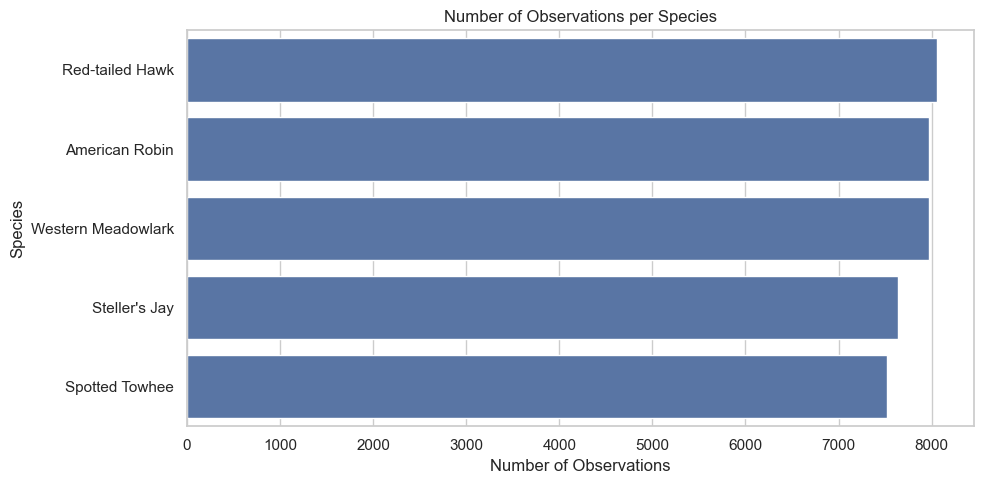

In [18]:
# Count observations per species
species_counts = df["species"].value_counts()

plt.figure(figsize=(10,5))
sns.barplot(
    x=species_counts.values,
    y=species_counts.index,
)
plt.title("Number of Observations per Species")
plt.xlabel("Number of Observations")
plt.ylabel("Species")

plt.tight_layout()
plt.savefig(
    "species_observation_counts.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

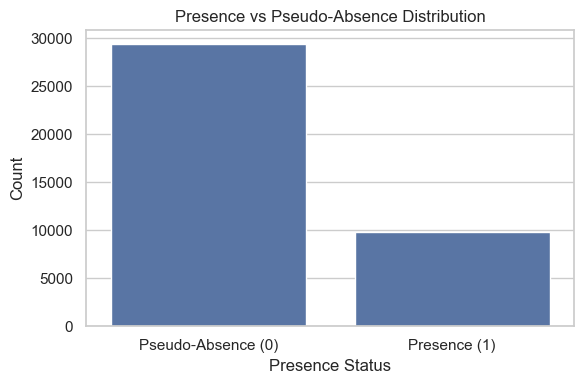

In [6]:
# Presence vs pseudo-absence plot

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="presence")

plt.title("Presence vs Pseudo-Absence Distribution")
plt.xlabel("Presence Status")
plt.ylabel("Count")
plt.xticks([0, 1], ["Pseudo-Absence (0)", "Presence (1)"])

plt.tight_layout()
plt.savefig("presence_vs_pseudoabsence_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

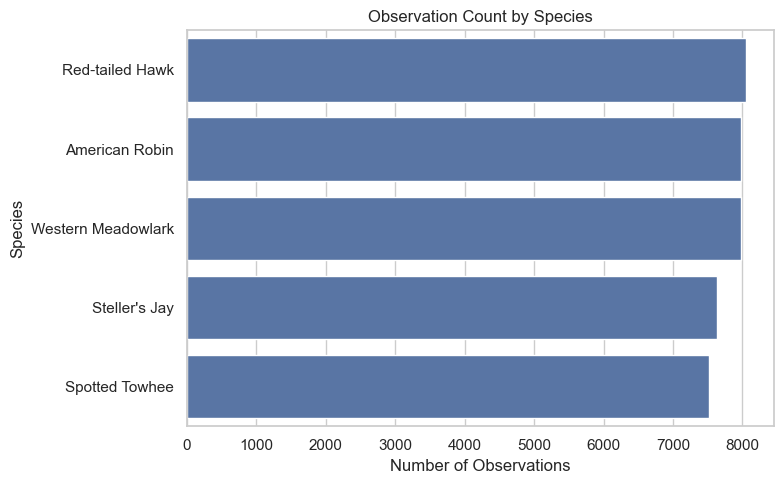

In [19]:
# Observation count by species

species_order = df["species"].value_counts().index

plt.figure(figsize=(8, 5))
sns.countplot(data=df, y="species", order=species_order)

plt.title("Observation Count by Species")
plt.xlabel("Number of Observations")
plt.ylabel("Species")

plt.tight_layout()
plt.savefig("species_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

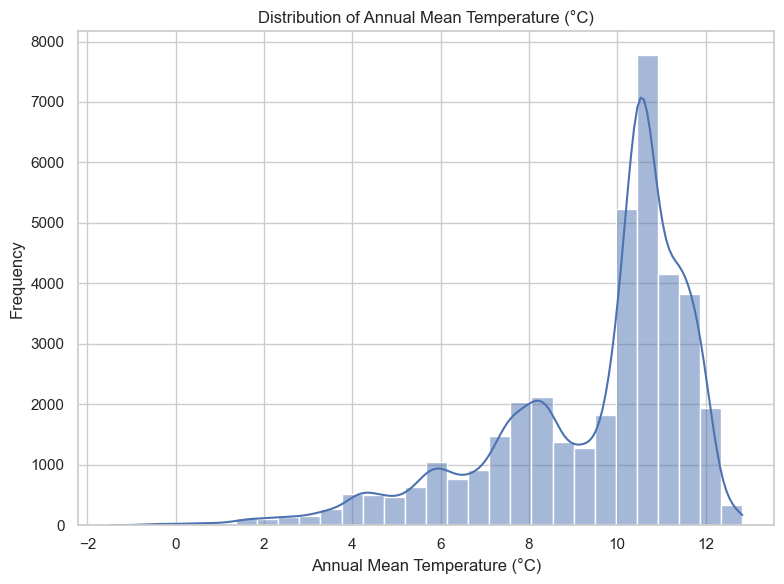

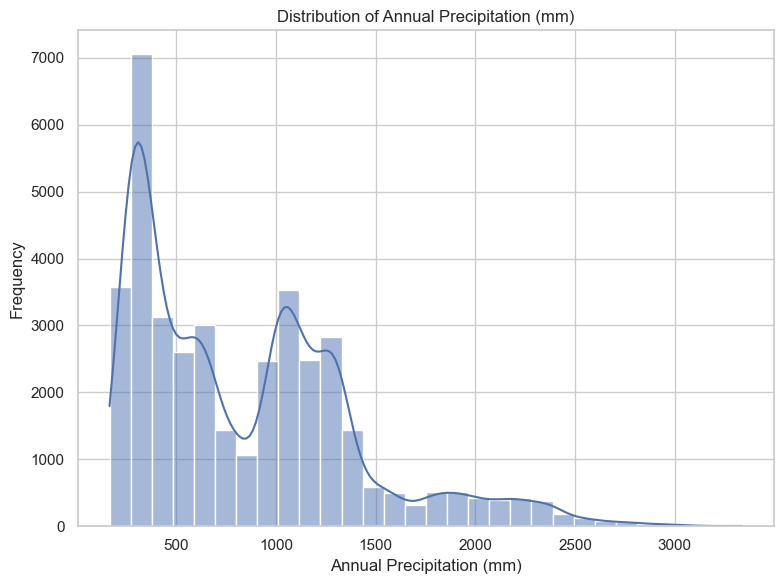

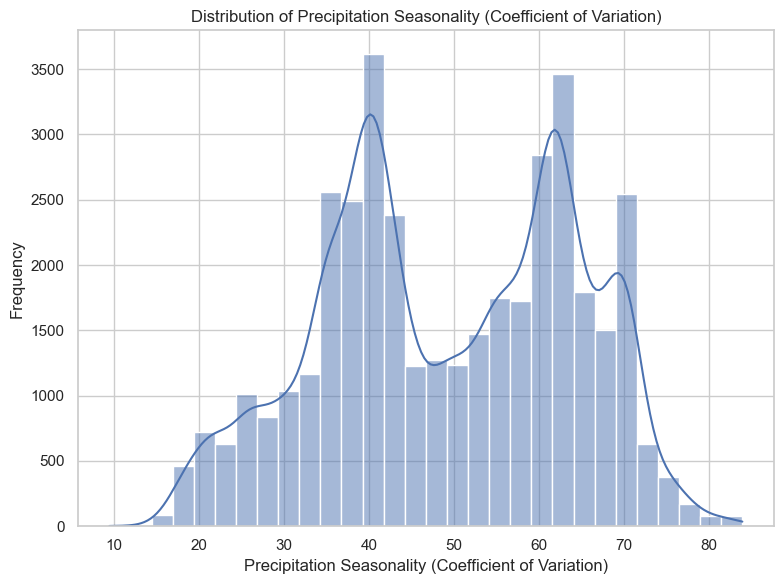

In [8]:
# Histograms for key climate variables

pretty_names = {
    "bio1_annual_mean_temp": "Annual Mean Temperature (°C)",
    "bio12_annual_precip": "Annual Precipitation (mm)",
    "bio15_precip_seasonality": "Precipitation Seasonality (Coefficient of Variation)"
}


climate_vars = [
    "bio1_annual_mean_temp",
    "bio12_annual_precip",
    "bio15_precip_seasonality"
]

for var in climate_vars:
    plt.figure(figsize=(8, 6))
    sns.histplot(df[var], bins=30, kde=True)

    plt.title(f"Distribution of {pretty_names[var]}")
    plt.xlabel(pretty_names[var])
    plt.ylabel("Frequency")

    filename = f"histogram_{var}.png"
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

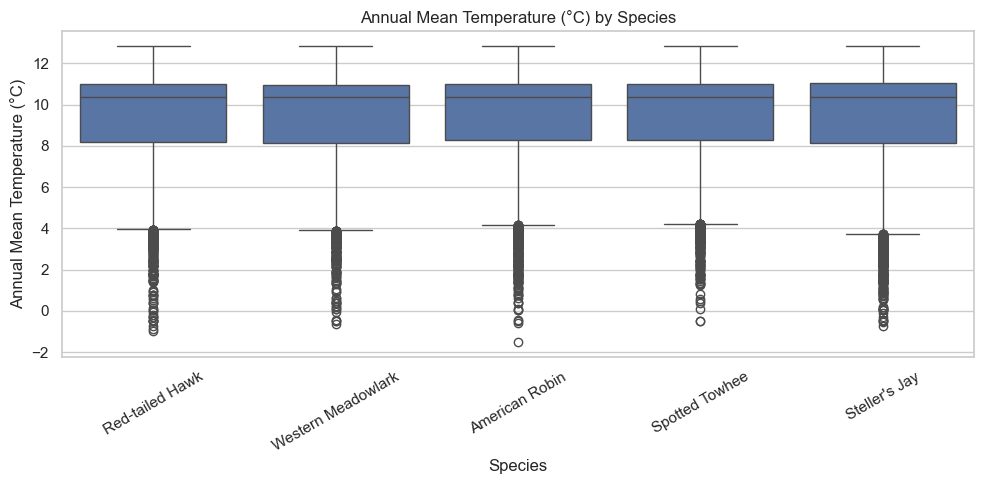

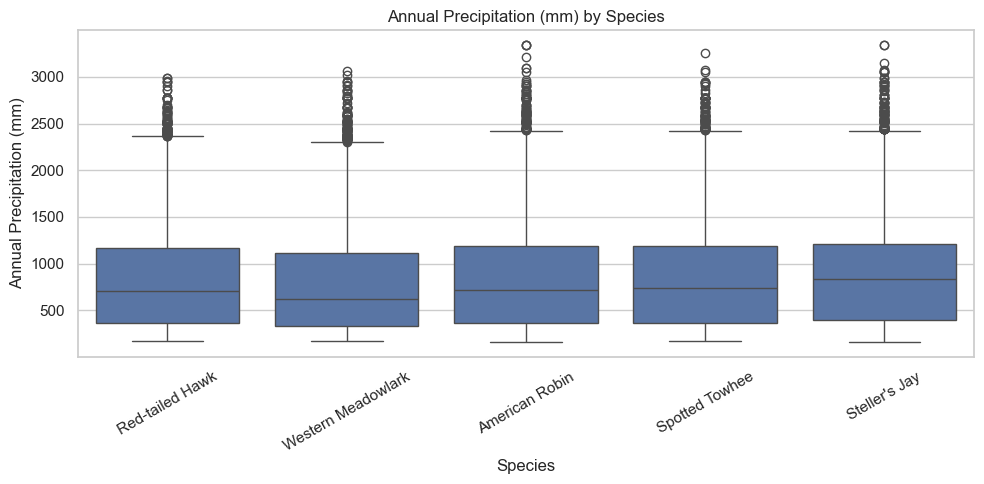

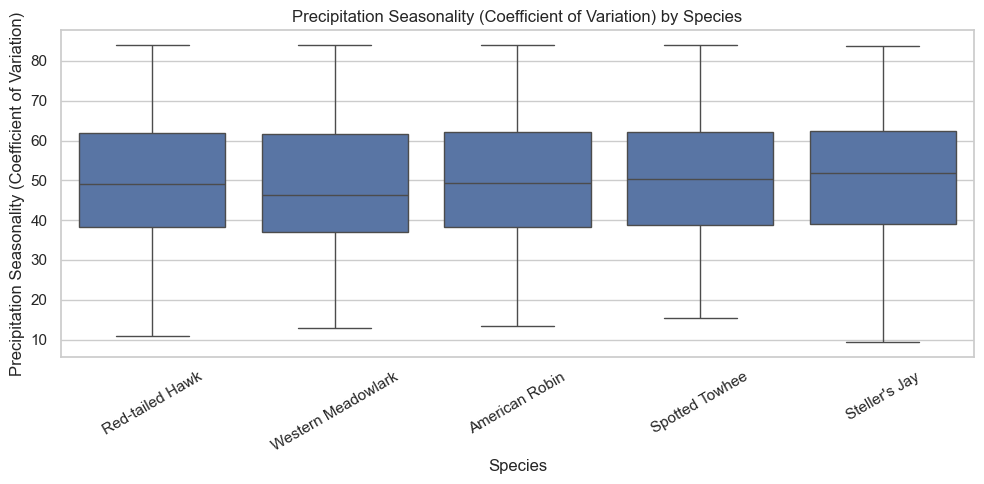

In [9]:
# Climate distributions by species

for var in climate_vars:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df, x="species", y=var)

    plt.title(f"{pretty_names[var]} by Species")
    plt.xlabel("Species")
    plt.ylabel(pretty_names[var])
    plt.xticks(rotation=30)

    filename = f"boxplot_{var}_by_species.png"

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")

    plt.show()

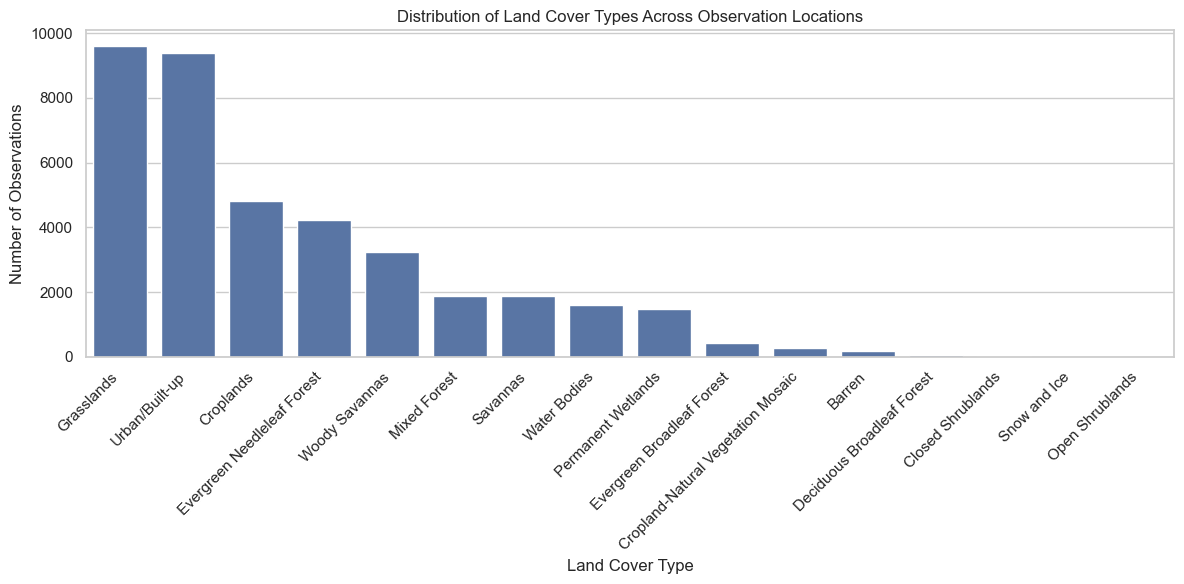

In [10]:
# Land cover distribution overall

land_cover_labels = {
    1: "Evergreen Needleleaf Forest",
    2: "Evergreen Broadleaf Forest",
    3: "Deciduous Needleleaf Forest",
    4: "Deciduous Broadleaf Forest",
    5: "Mixed Forest",
    6: "Closed Shrublands",
    7: "Open Shrublands",
    8: "Woody Savannas",
    9: "Savannas",
    10: "Grasslands",
    11: "Permanent Wetlands",
    12: "Croplands",
    13: "Urban/Built-up",
    14: "Cropland-Natural Vegetation Mosaic",
    15: "Snow and Ice",
    16: "Barren",
    17: "Water Bodies"
}

# using the code names instead of the number
df["land_cover_name"] = df["land_cover"].map(land_cover_labels)
land_cover_order = df["land_cover_name"].value_counts().index

plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="land_cover_name",
    order=land_cover_order
)

plt.title("Distribution of Land Cover Types Across Observation Locations")
plt.xlabel("Land Cover Type")
plt.ylabel("Number of Observations")


plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig(
    "landcover_distribution_overall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

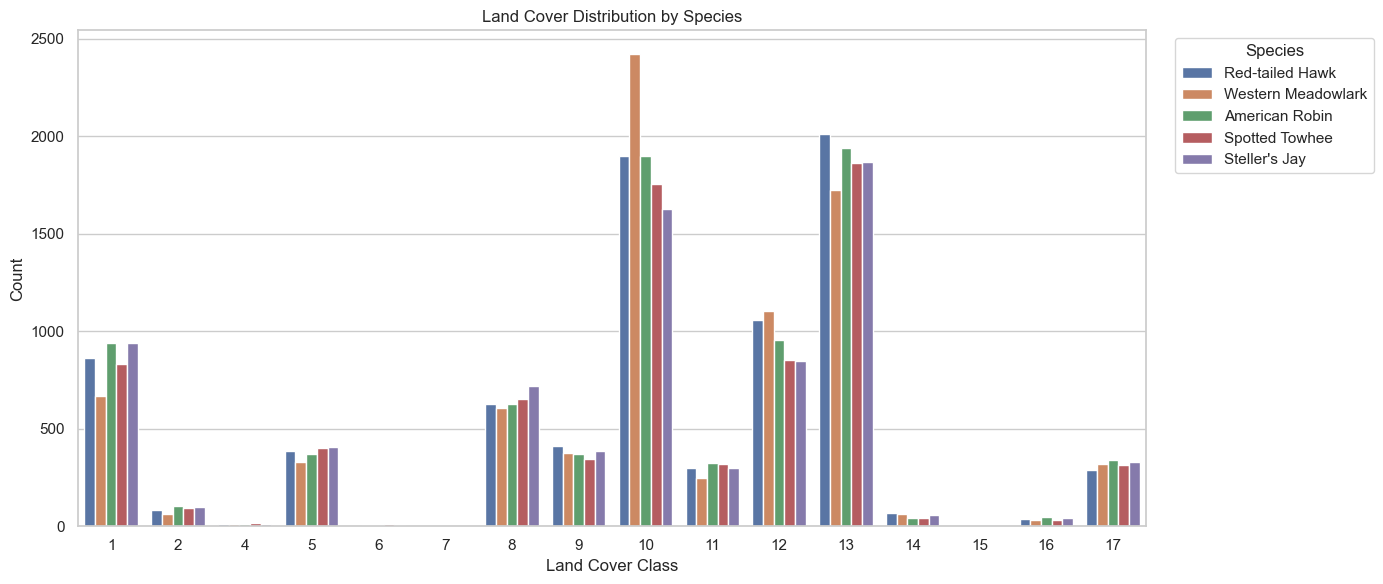

In [17]:
# Land cover distribution by species

land_cover_order_num = sorted(df["land_cover"].dropna().unique())
plt.figure(figsize=(14, 6))
sns.countplot(
    data=df,
    x="land_cover",
    hue="species",
    order=land_cover_order_num
)

plt.title("Land Cover Distribution by Species")
plt.xlabel("Land Cover Class")
plt.ylabel("Count")
plt.legend(title="Species", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.savefig("landcover_distribution_by_species.png", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
land_cover_reference = pd.DataFrame(
    {
        "land_cover_code": list(land_cover_labels.keys()),
        "land_cover_name": list(land_cover_labels.values())
    }
)

display(land_cover_reference)

,land_cover_code,land_cover_name
0,1,Evergreen Needleleaf Forest
1,2,Evergreen Broadleaf Forest
2,3,Deciduous Needleleaf Forest
3,4,Deciduous Broadleaf Forest
4,5,Mixed Forest
5,6,Closed Shrublands
6,7,Open Shrublands
7,8,Woody Savannas
8,9,Savannas
9,10,Grasslands


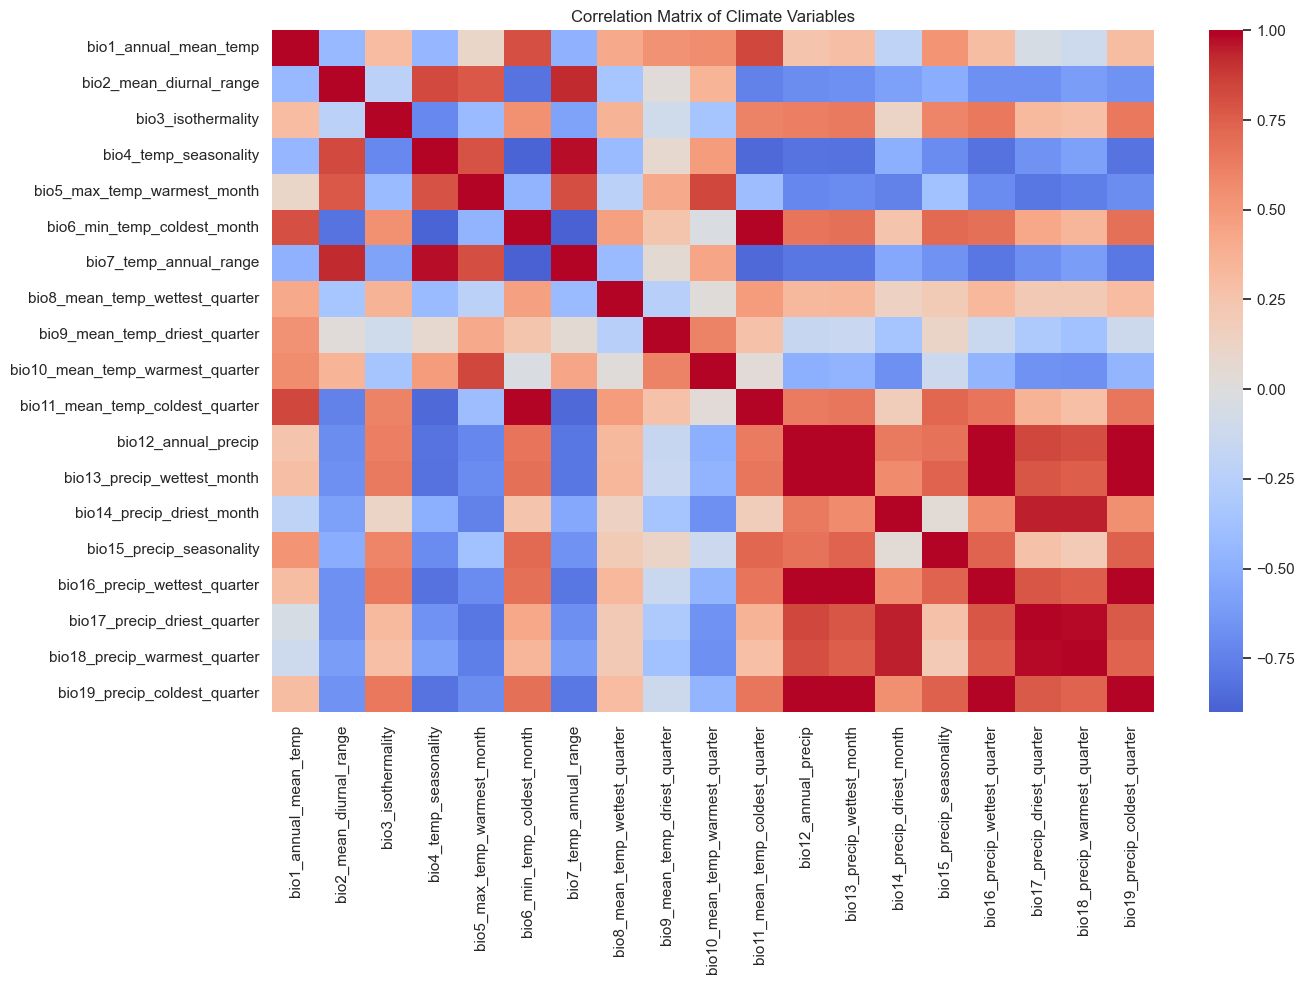

In [13]:
# Correlation heatmap for climate variables

climate_only = [
    "bio1_annual_mean_temp",
    "bio2_mean_diurnal_range",
    "bio3_isothermality",
    "bio4_temp_seasonality",
    "bio5_max_temp_warmest_month",
    "bio6_min_temp_coldest_month",
    "bio7_temp_annual_range",
    "bio8_mean_temp_wettest_quarter",
    "bio9_mean_temp_driest_quarter",
    "bio10_mean_temp_warmest_quarter",
    "bio11_mean_temp_coldest_quarter",
    "bio12_annual_precip",
    "bio13_precip_wettest_month",
    "bio14_precip_driest_month",
    "bio15_precip_seasonality",
    "bio16_precip_wettest_quarter",
    "bio17_precip_driest_quarter",
    "bio18_precip_warmest_quarter",
    "bio19_precip_coldest_quarter"
]

plt.figure(figsize=(14, 10))
corr_climate = df[climate_only].corr()

sns.heatmap(corr_climate, cmap="coolwarm", center=0)

plt.title("Correlation Matrix of Climate Variables")

plt.tight_layout()
plt.savefig("climate_variable_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
# Mean climate values by species

species_climate_summary = df.groupby("species")[climate_vars].mean()
species_climate_summary = species_climate_summary.rename(columns=pretty_names)

display(species_climate_summary)

,Annual Mean Temperature (°C),Annual Precipitation (mm),Precipitation Seasonality (Coefficient of Variation)
species,,,
American Robin,9.482911,861.146296,49.445455
Red-tailed Hawk,9.490511,841.983236,49.248571
Spotted Towhee,9.535247,863.263865,49.707712
Steller's Jay,9.415349,902.915652,50.373481
Western Meadowlark,9.440214,782.371332,48.146790


In [15]:
presence_summary = df.groupby("species")["presence"].mean().sort_values(ascending=False)
presence_summary = presence_summary.to_frame("presence_rate")

display(presence_summary)

,presence_rate
species,
Red-tailed Hawk,0.269713
American Robin,0.268647
Western Meadowlark,0.260973
Steller's Jay,0.231565
Spotted Towhee,0.218114


In [16]:
for species in df["species"].unique():

    print("=" * 80)
    print(species)

    species_df = df[df["species"] == species]

    land_cover_counts = (
        species_df["land_cover"]
        .value_counts()
        .sort_index()
        .rename(index=land_cover_labels)
        .to_frame("count")
    )

    display(land_cover_counts)

Red-tailed Hawk


,count
land_cover,
Evergreen Needleleaf Forest,862
Evergreen Broadleaf Forest,84
Deciduous Broadleaf Forest,12
Mixed Forest,387
Closed Shrublands,2
Woody Savannas,629
Savannas,410
Grasslands,1901
Permanent Wetlands,301


Western Meadowlark


,count
land_cover,
Evergreen Needleleaf Forest,670
Evergreen Broadleaf Forest,63
Deciduous Broadleaf Forest,12
Mixed Forest,330
Closed Shrublands,6
Woody Savannas,608
Savannas,374
Grasslands,2422
Permanent Wetlands,247


American Robin


,count
land_cover,
Evergreen Needleleaf Forest,938
Evergreen Broadleaf Forest,105
Deciduous Broadleaf Forest,11
Mixed Forest,373
Closed Shrublands,5
Woody Savannas,629
Savannas,368
Grasslands,1899
Permanent Wetlands,325


Spotted Towhee


,count
land_cover,
Evergreen Needleleaf Forest,832
Evergreen Broadleaf Forest,96
Deciduous Broadleaf Forest,19
Mixed Forest,399
Closed Shrublands,9
Woody Savannas,652
Savannas,343
Grasslands,1754
Permanent Wetlands,317


Steller's Jay


,count
land_cover,
Evergreen Needleleaf Forest,941
Evergreen Broadleaf Forest,97
Deciduous Broadleaf Forest,11
Mixed Forest,407
Closed Shrublands,4
Open Shrublands,1
Woody Savannas,717
Savannas,386
Grasslands,1628
